1. Import

In [2]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

2. Keypoints using MP Holistic (Holistic คือ Mediapipe ที่สามารถใช้ได้ทั้ง Face, Hand, Pose)

d:\Muayverse_Remake\.venv\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

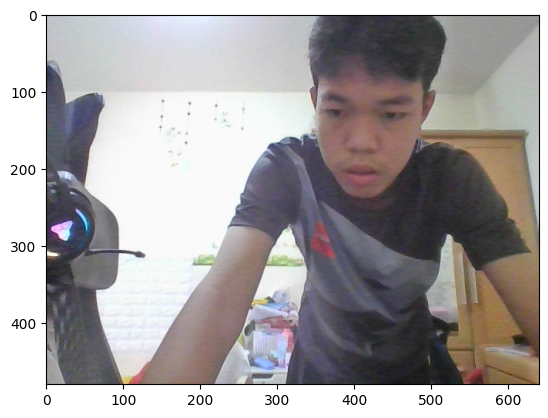

In [3]:
mp_holistic = mp.solutions.holistic   # Holistic model
mp_drawing = mp.solutions.drawing_utils   # Drawing utilities

# เปลี่ยนภาพ BGR เป็น RGB
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # แปลงสี BGR => RGB
    image.flags.writeable = False                  # ห้ามเขียนทับภาพชั่วคราว
    results = model.process(image)                 # ให้โมเดลทำนาย
    image.flags.writeable = True                   # อนุญาตเขียนทับภาพอีกครั้ง
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # แปลงสีกลับเป็น BGR
    return image, results

# Draw landmarks ลงบนจอ
def draw_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACE_CONNECTIONS) 
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS) 
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS)
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS) 

def draw_styled_landmarks(image, results): #กำหนดสีและขนาด landmarks 
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION, 
                             mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1), 
                             mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
                             ) 
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 

cap = cv2.VideoCapture(0)

# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # อ่านภาพจากกล้องทีละเฟรม
        ret, frame = cap.read()

        frame = cv2.flip(frame, 1)

        # ให้ MediaPipe ประมวลผลภาพ
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)

        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
cap.release()
cv2.destroyAllWindows()

plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# ลองดึงค่า pose ดูโครงสร้างข้อมูล
pose = []

# ดึงค่าจุดแกน x y z และ visibility ในแต่ละส่วน 
for res in results.pose_landmarks.landmark: # เก็บค่าทั้งหมดใน results โดยให้ res ดึง keypoint x y z v ทีละจุดจนครบ 33 จุด
    test = np.array([res.x, res.y, res.z, res.visibility]) 
    pose.append(test)
print(len(pose))      # 33 (จุดบนร่างกาย 33 จุด)
print(pose[0])        # [x, y, z, visibility] ของจุดที่ 0 (จมูก)
print(pose[0].shape)  # (4,)

3. ดึงค่า Keypoint จาก results มาแปลงในรูปแบบ Array 1 มิติ เพื่อเข้า LSTM

In [4]:
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

    return np.concatenate([pose, face, lh, rh])

result_test = extract_keypoints(results)

4. สร้างโฟลเดอร์, กำหนดข้อมูล ในการเก็บ dataset

In [5]:
DATA_PATH = os.path.join('MP_Data') # ชื่อโฟลเดอร์ที่เก็บข้อมูล
actions = np.array(['hello', 'thanks', 'iloveyou']) # สอนโมเดล 3 ท่า
no_sequences = 30 #เก็บ 30 คลิปในแต่ละท่า
sequence_length = 30 #เก็บ 30 เฟรมในแต่ละคลิป
start_folder = 0

# สร้างโฟลเดอร์
for action in actions: 
    for sequence in range(no_sequences):
        try: 
            os.makedirs(os.path.join(DATA_PATH, action, str(sequence)), exist_ok=True)
        except:
            pass

print(os.path.exists('MP_Data/hello/0'))   # ต้องได้ True

True


5. เก็บ Dataset

In [ ]:
cap = cv2.VideoCapture(0)

# Set mediapipe holistic model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:

    for action in actions: # loop ท่าทางที่กำหนด
        for sequence in range(start_folder, start_folder+no_sequences): # คลิปที่เท่าไหร่ (0-29) = 30 รอบ
            for frame_num in range(sequence_length): # เฟรมที่เท่าไหร่ (0-29) = 30 รอบ

                ret, frame = cap.read() # อ่านเฟรมจากกล้อง 
                frame = cv2.flip(frame, 1)
                image, results = mediapipe_detection(frame, holistic) #Detect landmarks
                draw_styled_landmarks(image, results) # Draw landmarks on webcam
                
                # NEW Apply wait logic
                if frame_num == 0: 
                    cv2.putText(image, 'STARTING COLLECTION', (120,200), 
                               cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255, 0), 4, cv2.LINE_AA)
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,12), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                    cv2.waitKey(500)
                else: 
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,12), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                
                # เอาพวก face pose hands มาแปลงเป็นตัวเลข
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
                np.save(npy_path, keypoints)

                # Break gracefully
                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break
                    
    cap.release()
    cv2.destroyAllWindows()

KeyboardInterrupt: 

: 

6. Preprocess Data and Create Labels and Features

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical # แปลงเลขท่าเป็นรูปแบบ one-hot

label_map = {label:num for num, label in enumerate(actions)} # {'hello': 0, 'thanks': 1, 'iloveyou': 2}

sequences, labels = [], []
for action in actions: # วนทีละท่า
    for sequence in np.array(os.listdir(os.path.join(DATA_PATH, action))).astype(int): # วนดูแต่ละ Sequence
        window = []
        for frame_num in range(sequence_length): # โหลด .npy ทีละเฟรม 
            res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

X = np.array(sequences) # Data ที่จะให้ Lstm เรียน 
y = to_categorical(labels).astype(int) # คำตอบที่ให้ AI ทาย

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=labels, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.2, stratify=np.argmax(y_temp, axis=1), random_state=42
)

7. Build and Train LSTM

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)

model = Sequential()

model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(30,1662)))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(actions.shape[0], activation='softmax'))

model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

model.fit(X_train, y_train, epochs=2000, validation_split=0.2, callbacks=[tb_callback, early_stop])

model.summary()

Epoch 1/2000
2/2 [==============================] - 6s 832ms/step - loss: 1.1134 - categorical_accuracy: 0.2600 - val_loss: 2.9042 - val_categorical_accuracy: 0.3077
Epoch 2/2000
2/2 [==============================] - 0s 166ms/step - loss: 2.5566 - categorical_accuracy: 0.3400 - val_loss: 2.1608 - val_categorical_accuracy: 0.3077
Epoch 3/2000
2/2 [==============================] - 0s 156ms/step - loss: 1.6203 - categorical_accuracy: 0.5200 - val_loss: 1.8544 - val_categorical_accuracy: 0.4615
Epoch 4/2000
2/2 [==============================] - 0s 331ms/step - loss: 2.3336 - categorical_accuracy: 0.4400 - val_loss: 1.2392 - val_categorical_accuracy: 0.4615
Epoch 5/2000
2/2 [==============================] - 0s 244ms/step - loss: 3.8759 - categorical_accuracy: 0.4200 - val_loss: 3.4511 - val_categorical_accuracy: 0.0000e+00
Epoch 6/2000
2/2 [==============================] - 0s 153ms/step - loss: 3.1388 - categorical_accuracy: 0.1800 - val_loss: 1.1487 - val_categorical_accuracy: 0.4615


8. Test

In [ ]:
colors = [(245, 117, 16), (117, 245, 16), (16, 117, 245)]

def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    for num, prob in enumerate(res):
        cv2.rectangle(output_frame, (0, 60 + num * 40), (int(prob * 100), 90 + num * 40), colors[num], -1)
        cv2.putText(output_frame, actions[num], (0, 85 + num * 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
    return output_frame

sequence = []
sentence = []
predictions = []
threshold = 0.7          # ต้องมั่นใจเกิน 70% ถึงจะแสดงผล

cap = cv2.VideoCapture(0)
try:
    with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.flip(frame, 1)                               # ต้องเหมือนตอนเก็บข้อมูล

            image, results = mediapipe_detection(frame, holistic)
            draw_styled_landmarks(image, results)

            # เก็บ keypoint 30 เฟรมล่าสุด (sliding window)
            keypoints = select_features(extract_keypoints(results), n_features)
            sequence.append(keypoints)
            sequence = sequence[-30:]

            if len(sequence) == 30:
                res = model.predict(np.expand_dims(sequence, axis=0), verbose=0)[0]
                predictions.append(np.argmax(res))

                # แสดงคำใหม่ก็ต่อเมื่อ 10 ผลล่าสุดตรงกันหมด และมั่นใจเกิน threshold
                if len(predictions) >= 10 and len(set(predictions[-10:])) == 1:
                    if res[np.argmax(res)] > threshold:
                        word = actions[np.argmax(res)]
                        if len(sentence) == 0 or word != sentence[-1]:
                            sentence.append(word)

                sentence = sentence[-5:]
                image = prob_viz(res, actions, image, colors)

            cv2.rectangle(image, (0, 0), (640, 40), (245, 117, 16), -1)
            cv2.putText(image, ' '.join(sentence), (3, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)

            cv2.imshow('OpenCV Feed', image)

            if cv2.waitKey(10) & 0xFF == ord('q'):
                break
finally:
    cap.release()
    cv2.destroyAllWindows()